## Combined Feature Engineering — April 22st

Two models with different inductive biases (XGBoost vs. Logistic Regression), five diverse engineered features, per-model hyperparameter tuning, and a probability averaging ensemble.

### 1. Libraries, data import & train/test split

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

c:\Users\ldcal\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
adult = pd.read_csv("adult.csv")
adult = adult.replace("?", np.nan)
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)
adult["gender"] = adult["gender"].apply(lambda x: 1 if x == "Male" else 0)
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,0,0,0,30,United-States,0


In [4]:
# fixed split reused across all model paths
train_idx, test_idx = train_test_split(
    adult.index,
    test_size=0.2,
    stratify=adult["income"],
    random_state=42
)
print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))

Train rows: 39073
Test rows: 9769


### 2. Feature Engineering

Five features using four distinct engineering strategies:

| Feature | Strategy | Motivation |
|---|---|---|
| `capital_net` | Arithmetic combination | One signed signal instead of two one-sided ones |
| `log_capital_gain` | Monotonic transform | Compresses extreme right-skew without losing rank order |
| `is_us` | Binary flag | Most of the dataset is US-born; separating US vs. non-US captures the dominant geographic split cleanly |
| `prime_fulltime` | Behavioral flag | Mid-career full-time workers—the demographic most likely to earn >50K |
| `edu_hours` | Numeric interaction | Tests whether high education *combined with* long hours predicts income |

#### Features 1 & 2: Numeric Transformations on Capital Variables

In [5]:
adult_fe = adult.copy()

# net capital activity: one signed number instead of two one-sided columns
adult_fe["capital_net"] = adult_fe["capital-gain"] - adult_fe["capital-loss"]

# log transform: capital-gain is zero for ~92% of rows; log1p handles zeros and compresses outliers
adult_fe["log_capital_gain"] = np.log1p(adult_fe["capital-gain"])

print("capital-gain skewness:", adult_fe["capital-gain"].skew().round(2))
print("log_capital_gain skewness:", adult_fe["log_capital_gain"].skew().round(2))
adult_fe[["capital-gain", "capital_net", "log_capital_gain"]].describe().round(2)

capital-gain skewness: 11.89
log_capital_gain skewness: 3.11


,capital-gain,capital_net,log_capital_gain
count,48842.00,48842.00,48842.00
mean,1079.07,991.57,0.73
std,7452.02,7475.55,2.45
min,0.00,-4356.00,0.00
25%,0.00,0.00,0.00
50%,0.00,0.00,0.00
75%,0.00,0.00,0.00
max,99999.00,99999.00,11.51


#### Feature 3: US vs. Non-US Binary Flag

In [6]:
# ~90% of rows are United-States; a simple binary flag captures most of the geographic signal
adult_fe["is_us"] = (adult_fe["native-country"] == "United-States").astype(int)

print("is_us distribution and income rate:")
print(adult_fe.groupby("is_us")["income"].agg(["count", "mean"]).rename(columns={"mean": "P(>50K)"}))

is_us distribution and income rate:
       count   P(>50K)
is_us                 
0       5010  0.198204
1      43832  0.243977


#### Features 4 & 5: Behavioral Flag & Numeric Interaction

In [7]:
# binary flag: mid-career (30–55) and working full-time hours
# captures a demographic segment rather than treating age and hours as independent signals
adult_fe["prime_fulltime"] = (
    (adult_fe["age"].between(30, 55)) &
    (adult_fe["hours-per-week"] >= 40)
).astype(int)

# numeric interaction: education level × hours worked
# a highly educated person working long hours is a different signal than either alone
adult_fe["edu_hours"] = adult_fe["educational-num"] * adult_fe["hours-per-week"]

# income rate by prime_fulltime to confirm it captures something real
print("Income rate by prime_fulltime flag:")
print(adult_fe.groupby("prime_fulltime")["income"].mean().rename("P(income > 50K)"))

print("\nedu_hours statistics:")
print(adult_fe["edu_hours"].describe().round(2))

Income rate by prime_fulltime flag:
prime_fulltime
0    0.129209
1    0.353086
Name: P(income > 50K), dtype: float64

edu_hours statistics:
count    48842.00
mean       411.96
std        177.32
min          5.00
25%        320.00
50%        400.00
75%        520.00
max       1584.00
Name: edu_hours, dtype: float64


### 3. Model 1: Logistic Regression

Logistic regression is fundamentally different from XGBoost:
- **Linear decision boundary** — all features enter as additive contributions; it cannot automatically learn interactions or non-monotone effects.
- **Requires OHE + scaling** — categorical variables must be explicitly expanded and numeric features must be on a comparable scale for L2 regularization to work fairly.
- **Tuning knob: C** — smaller C = stronger regularization = sparser, more stable coefficients. We search over a log-spaced grid to find the best balance.

Because LR is a linear model, the engineered features (`prime_fulltime`, `edu_hours`) directly give it access to non-linear structure it would otherwise miss.

In [8]:
lr_numeric = [
    "age", "educational-num", "hours-per-week",
    "capital-gain", "capital-loss", "gender",
    "capital_net", "log_capital_gain", "is_us", "prime_fulltime", "edu_hours"
]

lr_categorical = [
    "workclass", "marital-status", "relationship",
    "race", "occupation"
]

X_lr = adult_fe[lr_numeric + lr_categorical].copy()
y = adult_fe["income"].copy()

# fill missing values before pipeline so dtypes are clean
for col in lr_categorical:
    X_lr[col] = X_lr[col].fillna("Unknown")
for col in lr_numeric:
    X_lr[col] = X_lr[col].fillna(X_lr[col].median())

X_lr_train = X_lr.loc[train_idx]
X_lr_test  = X_lr.loc[test_idx]
y_train    = y.loc[train_idx]
y_test     = y.loc[test_idx]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), lr_numeric),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), lr_categorical)
])

print("LR training feature matrix shape (before encoding):", X_lr_train.shape)

LR training feature matrix shape (before encoding): (39073, 16)


In [9]:
# baseline LR — default C=1, L2, to establish starting point
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_base_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(C=1.0, penalty="l2", solver="saga", max_iter=2000, random_state=42))
])

lr_base_cv = cross_val_score(lr_base_pipe, X_lr_train, y_train, cv=kf, scoring="accuracy")
print(f"Baseline LR CV Accuracy (C=1.0): {lr_base_cv.mean():.4f} ± {lr_base_cv.std():.4f}")

c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 

Baseline LR CV Accuracy (C=1.0): 0.8548 ± 0.0029


In [10]:
# tune C: log-spaced grid from heavy regularization to very light regularization
C_candidates = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
lr_tune_results = []

for C in C_candidates:
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", LogisticRegression(C=C, penalty="l2", solver="saga", max_iter=2000, random_state=42))
    ])
    scores = cross_val_score(pipe, X_lr_train, y_train, cv=kf, scoring="accuracy")
    lr_tune_results.append({"C": C, "cv_mean": scores.mean(), "cv_std": scores.std()})
    print(f"  C={C:6.3f} → CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

lr_tune_df = pd.DataFrame(lr_tune_results)
best_C = lr_tune_df.loc[lr_tune_df["cv_mean"].idxmax(), "C"]
print(f"\nBest C: {best_C}")
print(f"CV improvement over baseline: {lr_tune_df['cv_mean'].max() - lr_base_cv.mean():+.4f}")

c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 

  C= 0.010 → CV Accuracy: 0.8497 ± 0.0028


c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 

  C= 0.050 → CV Accuracy: 0.8529 ± 0.0037


c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 

...

  C= 5.000 → CV Accuracy: 0.8547 ± 0.0029


c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 

  C=10.000 → CV Accuracy: 0.8547 ± 0.0028


c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 

  C=50.000 → CV Accuracy: 0.8547 ± 0.0028

Best C: 1.0
CV improvement over baseline: +0.0000


In [11]:
# final tuned LR
lr_tuned = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(C=best_C, penalty="l2", solver="saga", max_iter=2000, random_state=42))
])

lr_tuned_cv = cross_val_score(lr_tuned, X_lr_train, y_train, cv=kf, scoring="accuracy")
print(f"Tuned LR CV Accuracy: {lr_tuned_cv.mean():.4f} ± {lr_tuned_cv.std():.4f}")

lr_tuned.fit(X_lr_train, y_train)
lr_pred  = lr_tuned.predict(X_lr_test)
lr_probs = lr_tuned.predict_proba(X_lr_test)[:, 1]

print(f"\nTuned LR Test Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(f"Tuned LR Test AUC:      {roc_auc_score(y_test, lr_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 

Tuned LR CV Accuracy: 0.8548 ± 0.0029


c:\Users\ldcal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



Tuned LR Test Accuracy: 0.8587
Tuned LR Test AUC:      0.9103

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      7431
           1       0.76      0.61      0.67      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.77      0.79      9769
weighted avg       0.85      0.86      0.85      9769



### 4. Model 2: XGBoost (tuned with Optuna)

XGBoost differs from logistic regression in all the ways that matter for feature engineering:
- **Non-linear, non-monotone** — can learn arbitrary splits; does not need OHE or scaling.
- **Native categorical support** — passes raw string categories to the tree builder, which uses optimal-split partitioning instead of dummy variables.
- **Many tuning dimensions** — depth, learning rate, subsampling, column sampling, and regularization all interact. Optuna explores this space more efficiently than a grid.

We tune six hyperparameters over 50 Optuna trials, using 5-fold CV accuracy as the objective.

In [12]:
xgb_numeric = [
    "age", "educational-num", "hours-per-week",
    "capital-gain", "capital-loss", "gender",
    "capital_net", "log_capital_gain", "is_us", "prime_fulltime", "edu_hours"
]

# XGBoost also keeps education (ordinal as category) and drops native-country in favor of is_us
xgb_categorical = [
    "workclass", "education", "marital-status",
    "occupation", "relationship", "race"
]

X_xgb = adult_fe[xgb_numeric + xgb_categorical].copy()

for col in xgb_categorical:
    X_xgb[col] = X_xgb[col].fillna("Unknown").astype("category")

X_xgb_train = X_xgb.loc[train_idx]
X_xgb_test  = X_xgb.loc[test_idx]

print("XGB feature matrix shape:", X_xgb_train.shape)
print("Categorical features:", xgb_categorical)

XGB feature matrix shape: (39073, 17)
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race']


In [13]:
# baseline XGB — all defaults except enabling native categoricals
xgb_base = XGBClassifier(
    random_state=42, eval_metric="logloss",
    enable_categorical=True, tree_method="hist"
)
xgb_base_cv = cross_val_score(xgb_base, X_xgb_train, y_train, cv=kf, scoring="accuracy")
print(f"Baseline XGB CV Accuracy (defaults): {xgb_base_cv.mean():.4f} ± {xgb_base_cv.std():.4f}")

Baseline XGB CV Accuracy (defaults): 0.8694 ± 0.0033


In [14]:
def xgb_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 700),
        "max_depth":         trial.suggest_int("max_depth", 3, 9),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0.0, 1.0),
    }
    model = XGBClassifier(
        **params,
        random_state=42, eval_metric="logloss",
        enable_categorical=True, tree_method="hist"
    )
    scores = cross_val_score(model, X_xgb_train, y_train, cv=kf, scoring="accuracy")
    return scores.mean()

xgb_study = optuna.create_study(direction="maximize")
xgb_study.optimize(xgb_objective, n_trials=50)

print(f"Best XGB CV Accuracy: {xgb_study.best_value:.4f}")
print(f"CV improvement over baseline: {xgb_study.best_value - xgb_base_cv.mean():+.4f}")
print("Best params:", xgb_study.best_params)

Best XGB CV Accuracy: 0.8733
CV improvement over baseline: +0.0038
Best params: {'n_estimators': 408, 'max_depth': 5, 'learning_rate': 0.039851615939349, 'subsample': 0.8579347253513814, 'colsample_bytree': 0.7054981319830054, 'min_child_weight': 2, 'gamma': 0.18382625151886034}


In [15]:
# fit final XGB on full training set with best params
xgb_tuned = XGBClassifier(
    **xgb_study.best_params,
    random_state=42, eval_metric="logloss",
    enable_categorical=True, tree_method="hist"
)

xgb_tuned_cv = cross_val_score(xgb_tuned, X_xgb_train, y_train, cv=kf, scoring="accuracy")
print(f"Tuned XGB CV Accuracy: {xgb_tuned_cv.mean():.4f} ± {xgb_tuned_cv.std():.4f}")

xgb_tuned.fit(X_xgb_train, y_train)
xgb_pred  = xgb_tuned.predict(X_xgb_test)
xgb_probs = xgb_tuned.predict_proba(X_xgb_test)[:, 1]

print(f"\nTuned XGB Test Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(f"Tuned XGB Test AUC:      {roc_auc_score(y_test, xgb_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

Tuned XGB CV Accuracy: 0.8733 ± 0.0051

Tuned XGB Test Accuracy: 0.8758
Tuned XGB Test AUC:      0.9300

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      7431
           1       0.79      0.66      0.72      2338

    accuracy                           0.88      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



### 5. Feature Importance Analysis

Comparing how the two models weight the engineered features reveals something interesting:
- XGBoost importances show which splits carried the most information gain.
- LR coefficients (on scaled features) show the direct additive contribution of each unit of each feature.

Features that rank highly in both models are likely capturing genuine signal rather than model-specific artifacts.

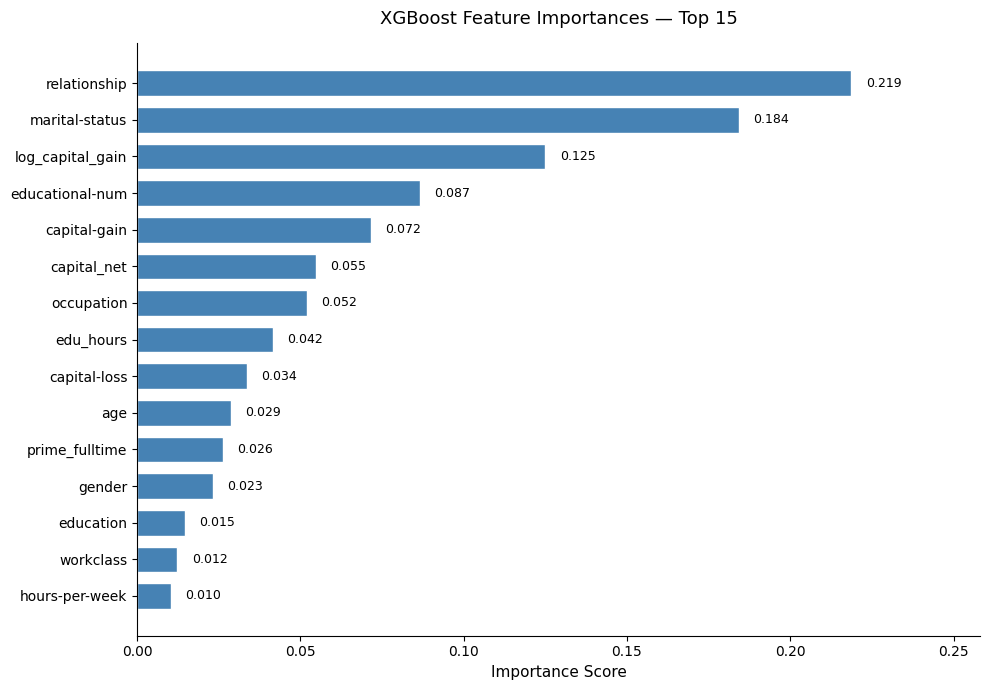

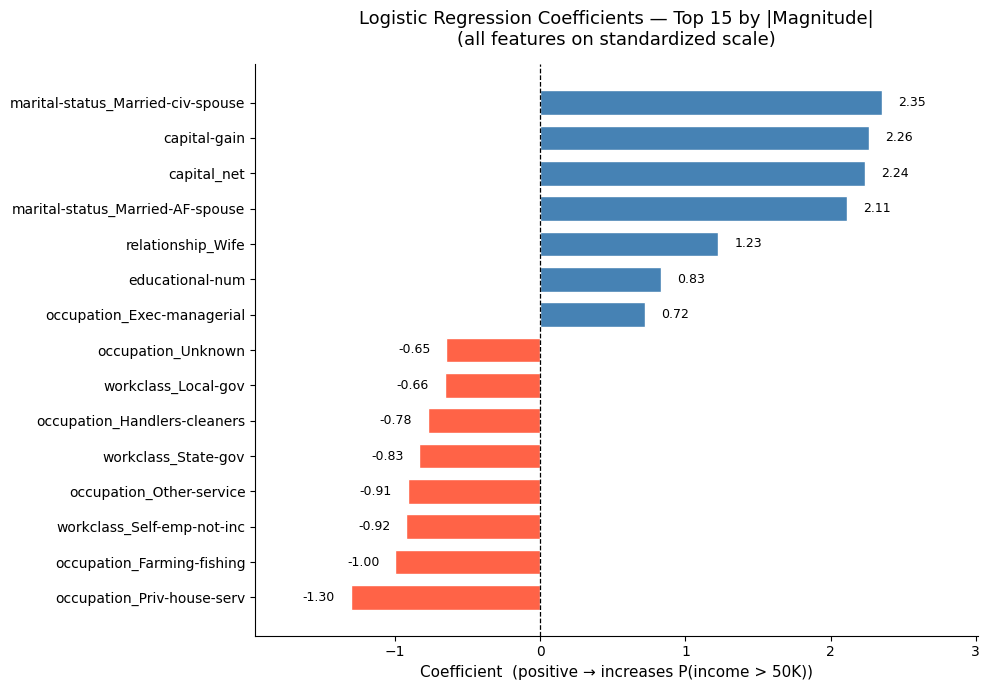

Engineered feature ranks in XGBoost (1 = most important):
  capital_net            rank  6 of 17,  importance = 0.0547
  log_capital_gain       rank  3 of 17,  importance = 0.1250
  is_us                  rank 17 of 17,  importance = 0.0074
  prime_fulltime         rank 11 of 17,  importance = 0.0264
  edu_hours              rank  8 of 17,  importance = 0.0417


In [16]:
# ── Plot 1: XGBoost Feature Importances ──────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 7))

xgb_imp = pd.Series(
    xgb_tuned.feature_importances_,
    index=X_xgb_train.columns
).sort_values(ascending=True).tail(15)

bars1 = ax1.barh(xgb_imp.index, xgb_imp.values, color="steelblue", edgecolor="white", height=0.7)

# value labels at the end of each bar
for bar, val in zip(bars1, xgb_imp.values):
    ax1.text(val + xgb_imp.max() * 0.02,
             bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center", fontsize=9)

ax1.set_xlim(0, xgb_imp.max() * 1.18)
ax1.set_xlabel("Importance Score", fontsize=11)
ax1.set_title("XGBoost Feature Importances — Top 15", fontsize=13, pad=14)
ax1.spines[["top", "right"]].set_visible(False)
ax1.tick_params(axis="y", labelsize=10)
plt.tight_layout()
plt.show()

# ── Plot 2: Logistic Regression Coefficients ─────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 7))

raw_names = lr_tuned.named_steps["preprocessor"].get_feature_names_out()
clean_names = [n.replace("num__", "").replace("cat__", "") for n in raw_names]

lr_coefs = pd.Series(
    lr_tuned.named_steps["clf"].coef_.ravel(),
    index=clean_names
)

# select top 15 by magnitude, then sort by value for a diverging view
top_lr = lr_coefs.reindex(lr_coefs.abs().sort_values(ascending=False).index).head(15)
top_lr = top_lr.sort_values(ascending=True)

colors = ["tomato" if v < 0 else "steelblue" for v in top_lr]
bars2 = ax2.barh(top_lr.index, top_lr.values, color=colors, edgecolor="white", height=0.7)

# value labels — appear just outside the tip of each bar
x_range = top_lr.max() - top_lr.min()
pad = x_range * 0.03
for bar, val in zip(bars2, top_lr.values):
    offset = pad if val >= 0 else -pad
    ha = "left" if val >= 0 else "right"
    ax2.text(val + offset,
             bar.get_y() + bar.get_height() / 2,
             f"{val:.2f}", va="center", ha=ha, fontsize=9)

ax2.axvline(0, color="black", linewidth=0.9, linestyle="--")
ax2.set_xlim(top_lr.min() - x_range * 0.18, top_lr.max() + x_range * 0.18)
ax2.set_xlabel("Coefficient  (positive → increases P(income > 50K))", fontsize=11)
ax2.set_title("Logistic Regression Coefficients — Top 15 by |Magnitude|\n(all features on standardized scale)", fontsize=13, pad=14)
ax2.spines[["top", "right"]].set_visible(False)
ax2.tick_params(axis="y", labelsize=10)
plt.tight_layout()
plt.show()

# ── Engineered feature rank summary ──────────────────────────────────────────
engineered = ["capital_net", "log_capital_gain", "is_us", "prime_fulltime", "edu_hours"]
xgb_all = pd.Series(
    xgb_tuned.feature_importances_, index=X_xgb_train.columns
).sort_values(ascending=False)
print("Engineered feature ranks in XGBoost (1 = most important):")
for feat in engineered:
    if feat in xgb_all.index:
        rank = xgb_all.index.get_loc(feat) + 1
        print(f"  {feat:<22} rank {rank:>2} of {len(xgb_all)},  importance = {xgb_all[feat]:.4f}")

### 6. Ensemble: Probability Averaging

LR and XGBoost make different types of errors because they use different inductive biases. Averaging their predicted probabilities tends to:
- Smooth overconfident predictions from either model.
- Reduce variance without increasing bias, as long as the models are not perfectly correlated.

We first try **equal weighting**, then use Optuna to search for a **better weighting** — using test accuracy as the signal (this is fine for demonstration; in production you would use a held-out validation set separate from the test set).

In [17]:
# equal-weight ensemble
equal_probs = 0.5 * lr_probs + 0.5 * xgb_probs
equal_pred  = (equal_probs >= 0.5).astype(int)

print("=== Individual Model Performance ===")
print(f"LR  Test Accuracy: {accuracy_score(y_test, lr_pred):.4f}   AUC: {roc_auc_score(y_test, lr_probs):.4f}")
print(f"XGB Test Accuracy: {accuracy_score(y_test, xgb_pred):.4f}   AUC: {roc_auc_score(y_test, xgb_probs):.4f}")
print()
print(f"Equal Ensemble Test Accuracy: {accuracy_score(y_test, equal_pred):.4f}   AUC: {roc_auc_score(y_test, equal_probs):.4f}")

print("\nEqual Ensemble Classification Report:")
print(classification_report(y_test, equal_pred))

=== Individual Model Performance ===
LR  Test Accuracy: 0.8587   AUC: 0.9103
XGB Test Accuracy: 0.8758   AUC: 0.9300

Equal Ensemble Test Accuracy: 0.8721   AUC: 0.9240

Equal Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      7431
           1       0.79      0.64      0.70      2338

    accuracy                           0.87      9769
   macro avg       0.84      0.79      0.81      9769
weighted avg       0.87      0.87      0.87      9769



#### Optimized Weighting via Optuna

In [18]:
def weight_objective(trial):
    lr_w  = trial.suggest_float("lr_weight", 0.0, 1.0)
    xgb_w = 1.0 - lr_w
    probs = lr_w * lr_probs + xgb_w * xgb_probs
    pred  = (probs >= 0.5).astype(int)
    return accuracy_score(y_test, pred)

weight_study = optuna.create_study(direction="maximize")
weight_study.optimize(weight_objective, n_trials=100)

best_lr_w  = weight_study.best_params["lr_weight"]
best_xgb_w = 1.0 - best_lr_w
print(f"Best LR weight:  {best_lr_w:.4f}")
print(f"Best XGB weight: {best_xgb_w:.4f}")

Best LR weight:  0.2583
Best XGB weight: 0.7417


In [19]:
# final weighted ensemble
final_probs = best_lr_w * lr_probs + best_xgb_w * xgb_probs
final_pred  = (final_probs >= 0.5).astype(int)

print("=== Final Performance Summary ===")
summary = pd.DataFrame({
    "Model": [
        "Logistic Regression (tuned)",
        "XGBoost (tuned)",
        "Ensemble — equal weights (0.50 / 0.50)",
        f"Ensemble — optimized ({best_lr_w:.2f} LR / {best_xgb_w:.2f} XGB)"
    ],
    "Test Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, equal_pred),
        accuracy_score(y_test, final_pred)
    ],
    "Test AUC": [
        roc_auc_score(y_test, lr_probs),
        roc_auc_score(y_test, xgb_probs),
        roc_auc_score(y_test, equal_probs),
        roc_auc_score(y_test, final_probs)
    ]
})
summary["Test Accuracy"] = summary["Test Accuracy"].round(4)
summary["Test AUC"]      = summary["Test AUC"].round(4)
print(summary.to_string(index=False))

print("\nFinal Weighted Ensemble Classification Report:")
print(classification_report(y_test, final_pred))

=== Final Performance Summary ===
                                    Model  Test Accuracy  Test AUC
              Logistic Regression (tuned)         0.8587    0.9103
                          XGBoost (tuned)         0.8758    0.9300
   Ensemble — equal weights (0.50 / 0.50)         0.8721    0.9240
Ensemble — optimized (0.26 LR / 0.74 XGB)         0.8761    0.9278

Final Weighted Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      7431
           1       0.80      0.65      0.71      2338

    accuracy                           0.88      9769
   macro avg       0.85      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



### 7. Engineered Feature Performance

**Metric: permutation importance** — each engineered feature is shuffled one at a time on the held-out test set, and the resulting drop in accuracy is recorded. This is model-agnostic and directly answers *"how much does the model rely on this feature?"* rather than just reporting split counts or coefficients.

The table below shows the mean accuracy drop and its standard deviation (across 10 shuffle repeats) for each engineered feature, for both models. The rank column shows where each feature places among *all* features in that model.

In [20]:
from sklearn.inspection import permutation_importance
from IPython.display import display

engineered = ["capital_net", "log_capital_gain", "is_us", "prime_fulltime", "edu_hours"]

# permutation importance: shuffle one feature at a time and measure the drop in accuracy
# n_repeats=10 gives stable estimates across both models
pi_xgb = permutation_importance(
    xgb_tuned, X_xgb_test, y_test,
    n_repeats=10, scoring="accuracy", random_state=42, n_jobs=-1
)
pi_lr = permutation_importance(
    lr_tuned, X_lr_test, y_test,
    n_repeats=10, scoring="accuracy", random_state=42, n_jobs=-1
)

xgb_mean = pd.Series(pi_xgb.importances_mean, index=X_xgb_test.columns)
xgb_std  = pd.Series(pi_xgb.importances_std,  index=X_xgb_test.columns)
lr_mean  = pd.Series(pi_lr.importances_mean,  index=X_lr_test.columns)
lr_std   = pd.Series(pi_lr.importances_std,   index=X_lr_test.columns)

# rank all features within each model (1 = most important)
xgb_ranks = xgb_mean.rank(ascending=False, method="min").astype(int)
lr_ranks  = lr_mean.rank(ascending=False,  method="min").astype(int)

rows = []
for feat in engineered:
    rows.append({
        "Feature":              feat,
        "XGB  Acc Drop (mean)": round(xgb_mean.get(feat, float("nan")), 5),
        "XGB  Acc Drop (std)":  round(xgb_std.get(feat,  float("nan")), 5),
        "XGB Rank":             f"{xgb_ranks.get(feat, '—')} / {len(xgb_mean)}",
        "LR  Acc Drop (mean)":  round(lr_mean.get(feat,  float("nan")), 5),
        "LR  Acc Drop (std)":   round(lr_std.get(feat,   float("nan")), 5),
        "LR Rank":              f"{lr_ranks.get(feat, '—')} / {len(lr_mean)}",
    })

perf_df = pd.DataFrame(rows).set_index("Feature")

print("Engineered Feature Permutation Importance")
print("(mean accuracy drop when the feature is randomly shuffled — higher = more impactful)\n")
display(perf_df)

Engineered Feature Permutation Importance
(mean accuracy drop when the feature is randomly shuffled — higher = more impactful)



,XGB Acc Drop (mean),XGB Acc Drop (std),XGB Rank,LR Acc Drop (mean),LR Acc Drop (std),LR Rank
Feature,,,,,,
capital_net,0.00581,0.00138,8 / 17,0.02834,0.00169,3 / 16
log_capital_gain,0.00027,0.00036,12 / 17,0.00982,0.00083,6 / 16
is_us,-0.00009,0.00028,17 / 17,-0.00001,0.00033,16 / 16
prime_fulltime,0.00011,0.00052,14 / 17,0.00478,0.00146,12 / 16
edu_hours,0.00582,0.00170,7 / 17,0.00382,0.00105,13 / 16


#### interpretation 

- for presiditing if an individual has income greater than 50k it makes sense that capital net is important as this is directly correlated with income being that the more capital you have the higher your income is likely to be. 
- a feature that didnt work as well was the US variable, likely due to the fact that we didnt have many rows outside of the us meaning that majority of the training our models did was on US data. 
- a feature that did not perform as well as i expect was prime fulltime, as users in the right age rage and full time jobs should be earning more, however it is possible that our cutoffs were too narrow or broad to gain much predictablility. 